In [1]:
# AmBe data fprompt neutron selection

import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import h5py
import numpy as np
import h5flow
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [ ]:
# DUNE plot style
import sys; sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "..", "utils"))
from dune_plot import apply_dune_style, dune_label
apply_dune_style()

In [2]:
# make an empty pandas dataframe to store the results
import pandas as pd
df = pd.DataFrame(columns=["time", "f_prompt", "num_fprompts", "num_high_fprompts"])

processing file:  /pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/60hz_timer_600tick/mpd_run_run2data_rctl_666_p19_v0p2.FLOW.hdf5
processing file:  /pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/60hz_timer_600tick/mpd_run_run2data_rctl_666_p11_v0p2.FLOW.hdf5
processing file:  /pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/60hz_timer_600tick/mpd_run_run2data_rctl_666_p25_v0p2.FLOW.hdf5
processing file:  /pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/60hz_timer_600tick/mpd_run_run2data_rctl_666_p36_v0p2.FLOW.hdf5
processing file:  /pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/60hz_timer_600tick/mpd_run_run2data_rctl_666_p13_v0p2.FLOW.hdf5
processing file:  /pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/60hz_timer_600tick/mpd_run_run2data_rctl_666_p9_v0p2.FLOW.hdf5
processing file:  /pscr

/global/homes/m/mnuland/.conda/envs/myenv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/global/homes/m/mnuland/.conda/envs/myenv/lib/python3.12/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


processing file:  /pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/two_trig_176us_period/mpd_run_run2data_rctl_621_p223_v0p2.FLOW.hdf5
processing file:  /pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/two_trig_176us_period/mpd_run_run2data_rctl_621_p286_v0p2.FLOW.hdf5
processing file:  /pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/two_trig_176us_period/mpd_run_run2data_rctl_621_p41_v0p2.FLOW.hdf5
processing file:  /pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/two_trig_176us_period/mpd_run_run2data_rctl_621_p98_v0p2.FLOW.hdf5
processing file:  /pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/two_trig_176us_period/mpd_run_run2data_rctl_621_p279_v0p2.FLOW.hdf5
processing file:  /pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/two_trig_176us_period/mpd_run_run2data_rctl_621_p103_v0p2.FLOW.hdf5


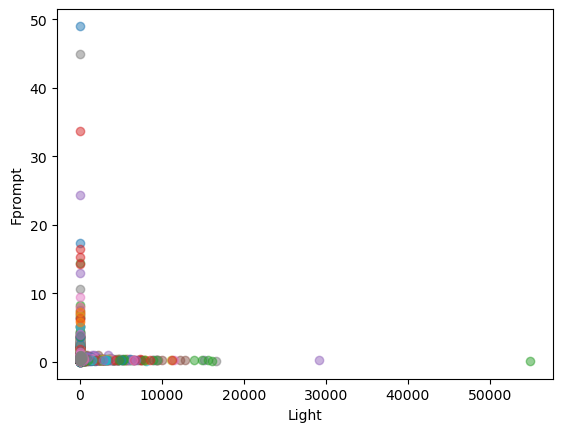

In [7]:
# Read all the folders in the base folder and get a single file from each folder
base_folder = "/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/" #"/global/cfs/cdirs/dune/users/mnuland/run2flow/matched_flowed_run2_new_gains"
folders = [f for f in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, f))]
files = []

for folder in folders:
    num_files = 0
    folder_path = os.path.join(base_folder, folder)
    for file in os.listdir(folder_path):
        num_files += 1
        if file.endswith(".hdf5") and num_files < 30:
            files.append(os.path.join(folder_path, file))
        else:
            continue


df = pd.DataFrame()
all_fprompts = []
all_lights = []
for path in files:

    file = h5flow.data.H5FlowDataManager(path, "r")
    print("processing file: ", path)

    try:
        fprompts = file["/light/sum_tpc_hits/data"]["fprompt"]
        light = file["/light/sum_tpc_hits/data"]["sum"]

        plt.scatter(light, fprompts, alpha=0.5)

        all_fprompts.extend(fprompts)
        all_lights.extend(light)

        avg_fprompt = np.mean(fprompts)
        num_fprompts_above_05 = np.sum(fprompts > 0.5)
        total_fprompts = len(fprompts)

        time = path.split("/")[-2][9:12]

        df1 = pd.DataFrame({
            "time": time,
            "f_prompt": avg_fprompt,
            "num_fprompts": total_fprompts,
            "num_high_fprompts": num_fprompts_above_05
        }, index=[0])

        df = pd.concat([df, df1], ignore_index=True)
    except KeyError:
        print(f"KeyError: 'fprompt' or 'sum' not found in file {path}")
        continue

# plot a heatmap of fprompt vs light

plt.xlabel("Light")
plt.ylabel("Fprompt")
plt.show()

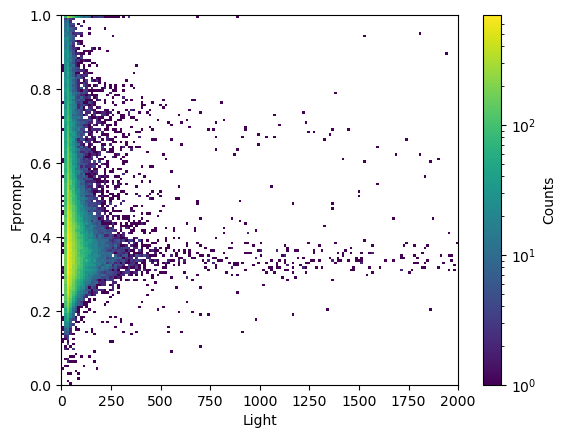

In [23]:
# plot a 2d heatmap of fprompt vs light dealing with nan values in either list appropiately
# mask the nan values in both lists
light_mask = np.isfinite(all_lights)
fprompt_mask = np.isfinite(all_fprompts)
combined_mask = light_mask & fprompt_mask
# apply the mask to both lists
all_lights = np.array(all_lights)[combined_mask]
all_fprompts = np.array(all_fprompts)[combined_mask]

plt.hist2d(all_lights, all_fprompts, bins=150, norm=LogNorm(), range=[[0, 2000], [0, 1]])
plt.xlabel("Light")
plt.ylabel("Fprompt")
plt.ylim(0,1)

plt.colorbar(label="Counts")
plt.show()

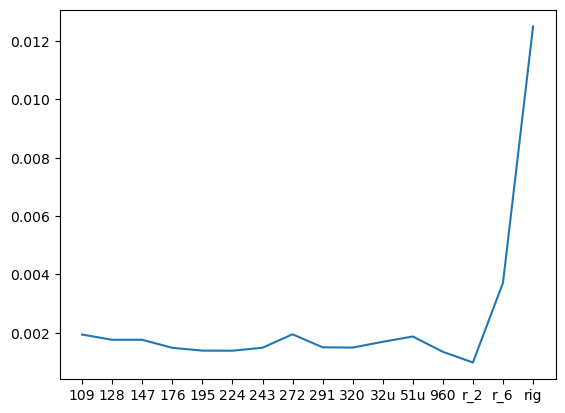

In [33]:
summary = df.groupby("time").sum()["f_prompt"]/df.groupby("time").sum()["num_fprompts"]
plt.plot(summary.index, summary.values)

In [4]:
h5flow_file = h5flow.data.H5FlowDataManager(path, mode="r")

In [5]:
# h5flow_file['/light/sum_tpc_hits/', '/light/events/', '/light/wvfm/']["samples"].shape # (211, 1, 1, 8, 64, 600)
h5flow_file['light/wvfm/', '/light/events/', '/light/sum_tpc_hits/'].dtype.names # (6418, 1, 2)

('id',
 'tpc',
 'trap_type',
 'sample_idx',
 'ns',
 'busy_ns',
 'samples',
 'sum',
 'max',
 'sum_spline',
 'max_spline',
 'ns_spline',
 'rising_spline',
 'rising_err_spline',
 'fwhm_spline',
 'integral',
 'fprompt',
 'tot',
 'tot_upper')

In [6]:
# Remove trailing 'u'
df["time"] = df["time"].str.replace("u", "", regex=False)

# Drop NaN values in second column
df = df.dropna(subset=["f_prompt"])

# Keep only purely numeric ids
df = df[df["time"].str.match(r"^\d+$")]

# Convert columns to numeric
df["time"] = pd.to_numeric(df["time"])
df["f_prompt"] = pd.to_numeric(df["f_prompt"], errors="coerce")
df["num_fprompts"] = pd.to_numeric(df["num_fprompts"], errors="coerce")
df["num_high_fprompts"] = pd.to_numeric(df["num_high_fprompts"], errors="coerce")


In [7]:
# Compute mean per id
avg = df.groupby("time")["f_prompt"].mean().reset_index()

# Compute standard deviation per id
std = df.groupby("time")["f_prompt"].std().reset_index()

# Compute count per id
count = df.groupby("time")["num_fprompts"].sum().reset_index()
# Compute count of high fprompts per id
count_high = df.groupby("time")["num_high_fprompts"].sum().reset_index()

# Ratio of high fprompts to total fprompts
count_high["ratio"] = count_high["num_high_fprompts"] / count["num_fprompts"]

# Error on the ratio
count_high["ratio_error"] = np.sqrt(count_high["ratio"] * (1 - count_high["ratio"]) / count["num_fprompts"])

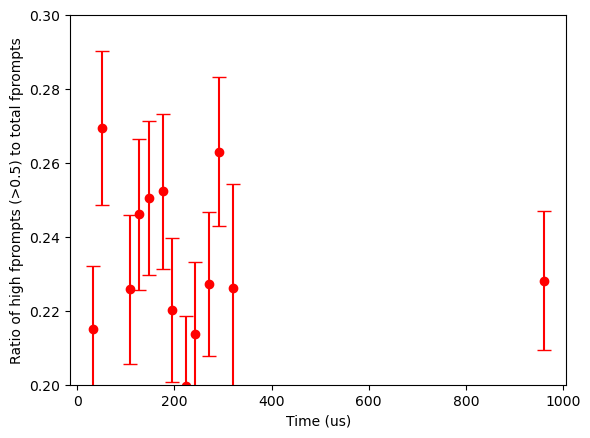

In [8]:
plt.figure()
plt.errorbar(avg["time"], count_high["ratio"], yerr=count_high["ratio_error"], fmt="o", color="r", capsize=5, label="Ratio of high fprompts to total fprompts")
plt.xlabel("Time (us)")
plt.ylabel("Ratio of high fprompts (>0.5) to total fprompts")
plt.ylim(0.2, 0.3)
plt.show()

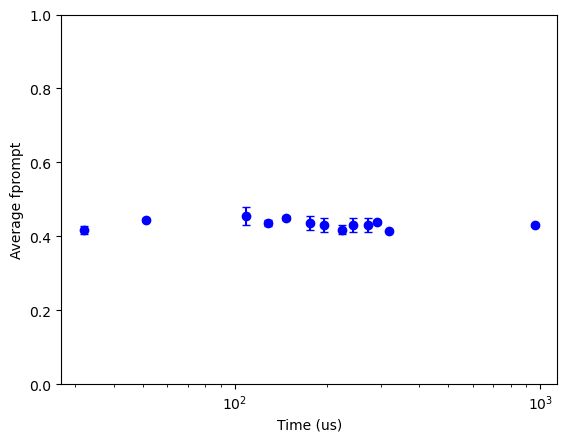

In [9]:

# Plot
plt.figure()
plt.errorbar(avg["time"], avg["f_prompt"], std["f_prompt"], ls="none", marker="o", capsize=3, color="blue")
plt.xlabel("Time (us)")
plt.ylabel("Average fprompt")
plt.ylim(0,1)
plt.xscale("log")
plt.show()

In [10]:
# Read file
path = "/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/two_trig_195us_period/mpd_run_run2data_rctl_641_p133_v0p2.FLOW.hdf5"
file = h5py.File(path, "r")

In [11]:
samples = file["/light/wvfm/data"]["samples"]
print(samples.shape)

(6420, 8, 64, 600)


In [12]:
# baseline correct the samples by subtracting the mean of the first 100 samples
baseline = np.mean(samples[:, :, :, :100], axis=3)
corrected_samples = samples - baseline[:, :, :, np.newaxis]

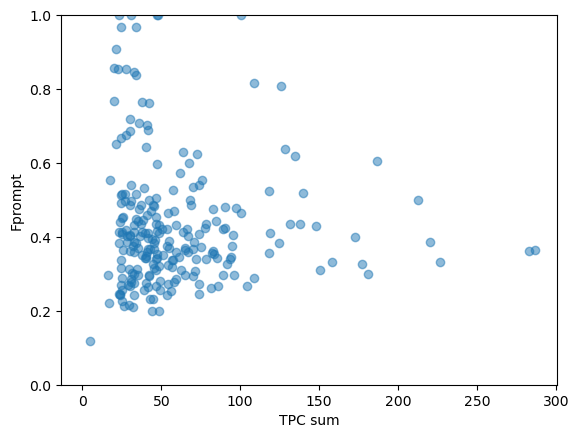

In [13]:
fprompts = file["/light/sum_tpc_hits/data"]["fprompt"]
light = file["/light/sum_tpc_hits/data"]["sum"]
plt.scatter(light, fprompts, alpha=0.5)
plt.ylim(0,1)
plt.xlabel("TPC sum")
plt.ylabel("Fprompt")
plt.show()

In [14]:
# for event in range(samples.shape[0]):
#     if np.sum(samples[event, 0, 16, :]) < 0:
#         print("PMT waveform", event)
        # plt.plot(samples[event, 0, 16, :])
        # plt.show()

In [15]:
def thd_correct(array):

    segment_size = 25
    n_ticks = array.shape[-1]
    n_segments = n_ticks // segment_size

    # reshape instead of advanced indexing
    trimmed = array[..., :n_segments*segment_size]
    segments = trimmed.reshape(*array.shape[:-1], n_segments, segment_size)

    ranges = np.ptp(segments, axis=-1)
    means = np.mean(segments, axis=-1)

    mask_zero = ranges != 0
    ranges = np.where(mask_zero, ranges, np.nan)
    means = np.where(mask_zero, means, np.nan)

    ordering = np.argsort(ranges, axis=-1)

    sorted_means = np.take_along_axis(means, ordering, axis=-1)

    average_mean = np.mean(sorted_means[..., 1:3], axis=-1)

    filtered_wvfm = array - average_mean[..., None]

    return filtered_wvfm

In [16]:
h5flow_file['light/wvfm/', '/light/events/', '/light/sum_tpc_hits/']['fprompt'][0]
fprompts = np.ma.filled(h5flow_file['light/wvfm/', '/light/events/', '/light/sum_tpc_hits/']['fprompt'], np.nan)
print(fprompts[100:200][:,0,0])

[      nan       nan       nan       nan       nan       nan       nan
       nan       nan       nan       nan       nan       nan       nan
       nan       nan       nan       nan       nan       nan       nan
       nan       nan       nan       nan       nan       nan       nan
       nan       nan       nan       nan       nan       nan       nan
       nan       nan       nan       nan       nan       nan       nan
       nan       nan       nan       nan       nan       nan       nan
       nan       nan       nan       nan       nan       nan       nan
       nan       nan       nan       nan       nan       nan       nan
       nan       nan       nan       nan       nan       nan       nan
       nan       nan       nan       nan       nan       nan       nan
       nan       nan       nan       nan       nan       nan       nan
       nan       nan       nan       nan 0.4931557       nan       nan
       nan       nan       nan       nan       nan       nan       nan
      

In [17]:
# offbeam_wvfm_v1 = h5flow_file['/light/sum_tpc_hits/', '/light/events/', '/light/wvfm/']["samples"][:, 0, 0, :, :, :500] # I took the first 500 ticks to switch between runs easily
# pmt_wvfm_v1 = offbeam_wvfm_v1[:,0,16,:]*(-1) # The PMT pulse has negative polarity
# pmt_wvfm_v2 = thd_correct(pmt_wvfm_v1/4) # This is a function I use to threshold correct, /4 to save on storage
# noise_sum_all = np.sum(pmt_wvfm_v2[:,5:100], axis=-1) # These are sums over empty noise, not a necessary step
# noise_sum_fast = np.sum(pmt_wvfm_v2[:,5:18], axis=-1) # These are sums over empty noise, not a necessary step
# fast_light = np.sum(pmt_wvfm_v2[:,105:118], axis=-1) - noise_sum_fast # the PMT waveform is always at the same position
# all_light = np.sum(pmt_wvfm_v2[:,105:200], axis=-1) - noise_sum_all
# fprompt_mask = ((fast_light/all_light) > 0.001)*((fast_light/all_light) < 0.2)
# thd_mask = (pmt_wvfm_v2[:,100:300] > 70) # require that the waveform have some width (there are these weird gaussians)
# pick_out_low = (np.sum(thd_mask[:,5:120], axis=-1) <= 15) # Require that it not just be PMT crosstalk or noise
# valid_trig = (fprompt_mask==1) * (pick_out_low==0) # Combine the masks
                        
# offbeam_wvfm_v2 = offbeam_wvfm_v1[valid_trig==1]  # apply the mask

In [19]:
# Let's plot some waveforms to see how it looks
# plt.plot(offbeam_wvfm_v2[0,0,16,:])
# plt.xlabel("Tick")
# plt.ylabel("ADC")
# plt.show()

In [85]:
# calculate the fprompt for the waveforms and compare to the fprompt from the sum_tpc_hits
samples = file['/light/sum_tpc_hits/', '/light/events/', '/light/wvfm/']["samples"][:, 0, 0, :, :, :500] # waveforms
# thd_corrected = thd_correct(samples[:,:,:,:]*(-1)/4)



In [95]:
TRAP_NAME_MAP = [
    # ----- ADC 0 (ACLs module 0, made-up names) -----
    dict(adc=0, channels=[4,5,6,7,8,9], name="ACL 2.01", tpc=0),               # -z, bottom, tpc 0
    dict(adc=0, channels=[10,11,12,13,14,15], name="ACL 2.02", tpc=0),         # -z, top, tpc 0
    dict(adc=0, channels=[20,21,22,23,24,25], name="ACL 2.03", tpc=0),         # +z bottom, tpc 0
    dict(adc=0, channels=[26,27,28,29,30,31], name="ACL 2.04", tpc=0),         # +z top, tpc 0
    dict(adc=0, channels=[52,53,54,55,56,57], name="ACL 2.05", tpc=1),         # -z bottom, tpc 1
    dict(adc=0, channels=[58,59,60,61,62,63], name="ACL 2.06", tpc=1),         # -z top, tpc 1
    dict(adc=0, channels=[36,37,38,39,40,41], name="ACL 2.07", tpc=1),         # +z bottom, tpc 1
    dict(adc=0, channels=[42,43,44,45,46,47], name="ACL 2.08", tpc=1),         # +z top, tpc 1
    
    # ----- ADC 1 (LCMs module 0, made-up names) -----
    dict(adc=1, channels=[4,5,6,7,8,9], name="LCM 100,101,102", tpc=0),        # -z, bottom, tpc 0
    dict(adc=1, channels=[10,11,12,13,14,15], name="LCM 103,104,105", tpc=0),  # -z, top, tpc 0
    dict(adc=1, channels=[20,21,22,23,24,25], name="LCM 106,107,108", tpc=0),  # +z bottom, tpc 0
    dict(adc=1, channels=[26,27,28,29,30,31], name="LCM 109,110,111", tpc=0),  # +z top, tpc 0
    dict(adc=1, channels=[52,53,54,55,56,57], name="LCM 112,113,114", tpc=1),  # -z bottom, tpc 1
    dict(adc=1, channels=[58,59,60,61,62,63], name="LCM 115,116,117", tpc=1),  # -z top, tpc 1
    dict(adc=1, channels=[36,37,38,39,40,41], name="LCM 118,119,120", tpc=1),  # +z bottom, tpc 1
    dict(adc=1, channels=[42,43,44,45,46,47], name="LCM 121,122,123", tpc=1),  # +z top, tpc 1
    
    # ----- ADC 2 (ACLs module 1, made-up names) -----
    dict(adc=2, channels=[4,5,6,7,8,9], name="ACL 2.09", tpc=2),               # -z, bottom, tpc 2
    dict(adc=2, channels=[10,11,12,13,14,15], name="ACL 2.10", tpc=2),         # -z, top, tpc 2
    dict(adc=2, channels=[20,21,22,23,24,25], name="ACL 2.11", tpc=2),         # +z bottom, tpc 2
    dict(adc=2, channels=[26,27,28,29,30,31], name="ACL 2.12", tpc=2),         # +z top, tpc 2
    dict(adc=2, channels=[52,53,54,55,56,57], name="ACL 2.13", tpc=3),         # -z bottom, tpc 3
    dict(adc=2, channels=[58,59,60,61,62,63], name="ACL 2.14", tpc=3),         # -z top, tpc 3
    dict(adc=2, channels=[36,37,38,39,40,41], name="ACL 2.15", tpc=3),         # +z bottom, tpc 3
    dict(adc=2, channels=[42,43,44,45,46,47], name="ACL 2.16", tpc=3),         # +z top, tpc 3

    # ----- ADC 3 (LCMs module 1, made-up names) -----
    dict(adc=3, channels=[20,21,22,23,24,25], name="LCM 124,125,126", tpc=2),  # -z, bottom, tpc 2
    dict(adc=3, channels=[26,27,28,29,30,31], name="LCM 127,128,129", tpc=2),  # -z, top, tpc 2
    dict(adc=3, channels=[4,5,6,7,8,9], name="LCM 130,131,132", tpc=2),        # +z bottom, tpc 2
    dict(adc=3, channels=[10,11,12,13,14,15], name="LCM 133,134,135", tpc=2),  # +z top, tpc 2
    dict(adc=3, channels=[52,53,54,55,56,57], name="LCM 136,137,138", tpc=3),  # -z bottom, tpc 3
    dict(adc=3, channels=[58,59,60,61,62,63], name="LCM 139,140,141", tpc=3),  # -z top, tpc 3
    dict(adc=3, channels=[36,37,38,39,40,41], name="LCM 142,143,144", tpc=3),  # +z bottom, tpc 3
    dict(adc=3, channels=[42,43,44,45,46,47], name="LCM 145,146,147", tpc=3),  # +z top, tpc 3

    # ----- ADC 4 (ACLs module 2, made-up names) -----
    dict(adc=4, channels=[42,43,44,45,46,47], name="ACL 2.17", tpc=4),         # -z, bottom, tpc 4
    dict(adc=4, channels=[36,37,38,39,40,41], name="ACL 2.18", tpc=4),         # -z, top, tpc 4
    dict(adc=4, channels=[52,53,54,55,56,57], name="LCM 148,149,150", tpc=4),  # -z top, tpc 4
    dict(adc=4, channels=[58,59,60,61,62,63], name="LCM 151,152,153", tpc=4),  # +z bottom, tpc 4
    dict(adc=4, channels=[26,27,28,29,30,31], name="ACL 2.19", tpc=5),         # -z bottom, tpc 5
    dict(adc=4, channels=[20,21,22,23,24,25], name="ACL 2.20", tpc=5),         # -z top, tpc 5
    dict(adc=4, channels=[10,11,12,13,14,15], name="ACL 2.21", tpc=5),         # +z bottom, tpc 5
    dict(adc=4, channels=[4,5,6,7,8,9], name="ACL 2.22", tpc=5),               # +z top, tpc 5

    # ----- ADC 5 (LCMs module 2, made-up names) -----
    dict(adc=5, channels=[42,43,44,45,46,47], name="LCM 154,155,156", tpc=4),  # -z, bottom, tpc 4
    dict(adc=5, channels=[58,59,60,61,62,63], name="ACL 2.23", tpc=4),         # +z, bottom, tpc 4
    dict(adc=5, channels=[52,53,54,55,56,57], name="ACL 2.24", tpc=4),         # +z top, tpc 4
    dict(adc=5, channels=[36,37,38,39,40,41], name="LCM 157,158,159", tpc=4),  # +z top, tpc 4
    dict(adc=5, channels=[26,27,28,29,30,31], name="LCM 160,161,162", tpc=5),  # -z bottom, tpc 5
    dict(adc=5, channels=[20,21,22,23,24,25], name="LCM 163,164,165", tpc=5),  # -z top, tpc 5
    dict(adc=5, channels=[10,11,12,13,14,15], name="LCM 166,167,168", tpc=5),  # +z bottom, tpc 5
    dict(adc=5, channels=[4,5,6,7,8,9], name="LCM 169,170,171", tpc=5),        # +z top, tpc 5

    # ----- ADC 6 (ACLs module 3, made-up names) -----
    dict(adc=6, channels=[4,5,6,7,8,9], name="ACL 2.25", tpc=6),               # -z, bottom, tpc 6
    dict(adc=6, channels=[10,11,12,13,14,15], name="ACL 2.26", tpc=6),         # -z, top, tpc 6
    dict(adc=6, channels=[20,21,22,23,24,25], name="ACL 2.27", tpc=6),         # +z bottom, tpc 6
    dict(adc=6, channels=[26,27,28,29,30,31], name="ACL 2.28", tpc=6),         # +z top, tpc 6
    dict(adc=6, channels=[52,53,54,55,56,57], name="ACL 2.29", tpc=7),         # -z bottom, tpc 7
    dict(adc=6, channels=[58,59,60,61,62,63], name="ACL 2.30", tpc=7),         # -z top, tpc 7
    dict(adc=6, channels=[36,37,38,39,40,41], name="ACL 2.31", tpc=7),         # +z bottom, tpc 7
    dict(adc=6, channels=[42,43,44,45,46,47], name="ACL 2.32", tpc=7),         # +z top, tpc 7

    # ----- ADC 7 (LCMs module 3, made-up names) -----
    dict(adc=7, channels=[4,5,6,7,8,9], name="LCM 172,173,174", tpc=6),        # -z, bottom, tpc 6
    dict(adc=7, channels=[10,11,12,13,14,15], name="LCM 175,176,177", tpc=6),  # -z, top, tpc 6
    dict(adc=7, channels=[20,21,22,23,24,25], name="LCM 178,179,180", tpc=6),  # +z bottom, tpc 6
    dict(adc=7, channels=[26,27,28,29,30,31], name="LCM 181,182,183", tpc=6),  # +z top, tpc 6
    dict(adc=7, channels=[52,53,54,55,56,57], name="LCM 184,185,186", tpc=7),  # -z bottom, tpc 7
    dict(adc=7, channels=[58,59,60,61,62,63], name="LCM 187,188,189", tpc=7),  # -z top, tpc 7
    dict(adc=7, channels=[36,37,38,39,40,41], name="LCM 190,191,192", tpc=7),  # +z bottom, tpc 7
    dict(adc=7, channels=[42,43,44,45,46,47], name="LCM 193,194,195", tpc=7),  # +z top, tpc 7
]

In [145]:
# transform samples from (events, adcs, channels, ticks) to (events, tpc, ticks) by summing over all appropriate channels for each tpc
tpc_samples = np.zeros((samples.shape[0], 8, samples.shape[-1])) # 8 tpcs, 8 adcs with 64 channels each
samples = thd_correct(samples)
for mapping in TRAP_NAME_MAP:
    adc = mapping["adc"]
    channels = mapping["channels"]
    tpc_index = mapping["tpc"] # extract tpc index from name
    tpc_samples[:, tpc_index, :] += np.sum(samples[:, adc, channels, :], axis=1)
# now we find the peak of the waveform in each tpc and sum the fprompt in a window around that peak, then divide by the total light in that tpc to get an fprompt for each tpc
fprompts_per_tpc = np.zeros((samples.shape[0], 8))
ticks = np.arange(tpc_samples.shape[-1])
for tpc in range(8):
    peak_tick = np.argmax(tpc_samples[:, tpc, :], axis=1)

    fast_start = np.clip(peak_tick - 5, 0, len(ticks))
    fast_end   = np.clip(peak_tick + 15, 0, len(ticks))

    total_start = np.clip(peak_tick - 5, 0, len(ticks))
    total_end   = np.clip(peak_tick + 195, 0, len(ticks))
    fast_mask = (ticks >= fast_start[:, None]) & (ticks < fast_end[:, None])
    total_mask = (ticks >= total_start[:, None]) & (ticks < total_end[:, None])
    fast_light = np.sum(tpc_samples[:, tpc, :] * fast_mask, axis=1)
    total_light = np.sum(tpc_samples[:, tpc, :] * total_mask, axis=1)
    fprompts_per_tpc[:, tpc] = fast_light / total_light

In [147]:
print(fprompts_per_tpc.shape)

(226, 8)


In [138]:
print(file['/light/sum_tpc_hits/', '/light/events/', '/light/wvfm/']["samples"].shape)
print(file['light/wvfm/', '/light/events/', '/light/sum_tpc_hits/']['fprompt'].shape)


(213, 1, 1, 8, 64, 600)
(6188, 1, 2)


In [180]:
# Ok, now let us read the files, select the events with a good trigger, then save the fprompt for the events following a good trigger
# Read all the folders in the base folder and get a single file from each folder
base_folder = "/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/"
folders = [f for f in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, f))]
files = []

fprompts_list = []
num_events_per_file = []
filenames = []
records = []

for folder in folders:
    num_files = 0
    folder_path = os.path.join(base_folder, folder)
    for file in os.listdir(folder_path):
        num_files += 1
        if file.endswith(".hdf5") and num_files < 40:
            files.append(os.path.join(folder_path, file))
        else:
            continue


for path in files:
    try:
        # file = h5py.File(path, "r")
        file = h5flow.data.H5FlowDataManager(path, mode="r")
        samples = file['/light/sum_tpc_hits/', '/light/events/', '/light/wvfm/']["samples"][:, 0, 0, :, :, :500] # I took the first 500 ticks to switch between runs easily
        samples = thd_correct(samples)
        pmt_wvfm_v2 = samples[:, 0, 16, :]*(-0.25) # The PMT pulse has negative polarity
        # pmt_wvfm_v2 = thd_correct(pmt_wvfm_v1/4) # This is a function I use to threshold correct, /4 to save on storage
        noise_sum_all = np.sum(pmt_wvfm_v2[:,5:100], axis=-1) # These are sums over empty noise, not a necessary step
        noise_sum_fast = np.sum(pmt_wvfm_v2[:,5:18], axis=-1) # These are sums over empty noise, not a necessary step
        fast_light = np.sum(pmt_wvfm_v2[:,105:118], axis=-1) - noise_sum_fast # the PMT waveform is always at the same position
        all_light = np.sum(pmt_wvfm_v2[:,105:200], axis=-1) - noise_sum_all
        ratio = fast_light / all_light
        fprompt_mask = (ratio > 0.001) & (ratio < 0.2)
        thd_mask = (pmt_wvfm_v2[:,100:300] > 70) # require that the waveform have some width (there are these weird gaussians)
        pick_out_low = (np.sum(thd_mask[:,5:120], axis=-1) <= 15) # Require that it not just be PMT crosstalk or noise
        valid_trig = fprompt_mask & (~pick_out_low) # Combine the masks
        # now we find the event right after the valid trigger and save the fprompt for that event
        # transform samples from (events, adcs, channels, ticks) to (events, tpc, ticks) by summing over all appropriate channels for each tpc
        # tpc_samples = np.zeros((samples.shape[0], 8, samples.shape[-1])) # 8 tpcs, 8 adcs with 64 channels each
        # for mapping in TRAP_NAME_MAP:
        #     adc = mapping["adc"]
        #     channels = mapping["channels"]
        #     tpc_index = mapping["tpc"] # extract tpc index from name
        #     tpc_samples[:, tpc_index, :] += np.sum(samples[:, adc, channels, :], axis=1)
        # # now we find the peak of the waveform in each tpc and sum the fprompt in a window around that peak, then divide by the total light in that tpc to get an fprompt for each tpc
        # fprompts_per_tpc = np.zeros((samples.shape[0], 8))
        # ticks = np.arange(tpc_samples.shape[-1])
        # for tpc in range(8):
        #     peak_tick = np.argmax(tpc_samples[:, tpc, :], axis=1)

        #     fast_start = np.clip(peak_tick - 5, 0, len(ticks))
        #     fast_end   = np.clip(peak_tick + 15, 0, len(ticks))

        #     total_start = np.clip(peak_tick - 5, 0, len(ticks))
        #     total_end   = np.clip(peak_tick + 195, 0, len(ticks))
        #     fast_mask = (ticks >= fast_start[:, None]) & (ticks < fast_end[:, None])
        #     total_mask = (ticks >= total_start[:, None]) & (ticks < total_end[:, None])
        #     fast_light = np.sum(tpc_samples[:, tpc, :] * fast_mask, axis=1)
        #     total_light = np.sum(tpc_samples[:, tpc, :] * total_mask, axis=1)
        #     fprompts_per_tpc[:, tpc] = fast_light / total_light
        fprompts = np.ma.filled(file['light/wvfm/', '/light/events/', '/light/sum_tpc_hits/']['fprompt'], np.nan)[:,0,0]
        tpc = np.ma.filled(file['light/wvfm/', '/light/events/', '/light/sum_tpc_hits/']['tpc'], 100)[:,0,0]
        tpc_sum = np.ma.filled(file['light/wvfm/', '/light/events/', '/light/sum_tpc_hits/']['integral'], np.nan)[:,0,0]
        valid_events = np.where(valid_trig==1)[0]

        valid_next = valid_events + 1
        valid_next = valid_next[valid_next < len(fprompts)]

        records.extend(
            {
                "filename": path,
                "fprompt": fprompts[i],
                "tpc": tpc[i],
                "tpc_sum": tpc_sum[i],
                "fprompt_calc": fprompts_per_tpc[i, tpc[i]] if tpc[i]<8 else np.nan,
                "valid_ev": i,
            }
            for i in valid_next
        )

        print(f"{path}: valid triggers={len(valid_events)}, appended={len(valid_next)}")

    except Exception as e:
        print(f"Error processing file {path}: {e}")


/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/60hz_timer_600tick/mpd_run_run2data_rctl_666_p19_v0p2.FLOW.hdf5: valid triggers=0, appended=0
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/60hz_timer_600tick/mpd_run_run2data_rctl_666_p11_v0p2.FLOW.hdf5: valid triggers=0, appended=0
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/60hz_timer_600tick/mpd_run_run2data_rctl_666_p25_v0p2.FLOW.hdf5: valid triggers=0, appended=0
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/60hz_timer_600tick/mpd_run_run2data_rctl_666_p36_v0p2.FLOW.hdf5: valid triggers=0, appended=0
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/60hz_timer_600tick/mpd_run_run2data_rctl_666_p13_v0p2.FLOW.hdf5: valid triggers=0, appended=0
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/60hz_timer_600tick/mpd_run_run2data_rctl_666

/tmp/ipykernel_1994322/1210765253.py:63: RuntimeWarning: divide by zero encountered in divide
  fprompts_per_tpc[:, tpc] = fast_light / total_light


/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/two_trig_195us_period/mpd_run_run2data_rctl_641_p28_v0p2.FLOW.hdf5: valid triggers=137, appended=137
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/two_trig_195us_period/mpd_run_run2data_rctl_641_p80_v0p2.FLOW.hdf5: valid triggers=138, appended=138
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/two_trig_195us_period/mpd_run_run2data_rctl_641_p61_v0p2.FLOW.hdf5: valid triggers=134, appended=134
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/two_trig_195us_period/mpd_run_run2data_rctl_641_p133_v0p2.FLOW.hdf5: valid triggers=127, appended=127
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/two_trig_195us_period/mpd_run_run2data_rctl_641_p53_v0p2.FLOW.hdf5: valid triggers=124, appended=124
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/two_trig

KeyboardInterrupt: 

In [184]:

df_fprompts = pd.DataFrame(records)
        


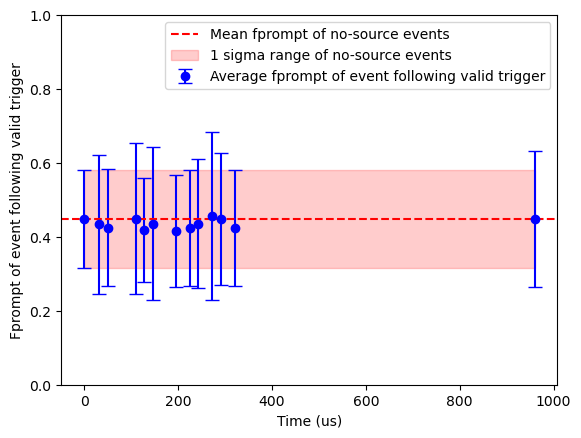

In [185]:
# use num_events_per_file to get the filenames matched to the fprompts_list
# filenames_expanded = []
# for i, num in enumerate(num_events_per_file):
#     filenames_expanded.extend([filenames[i]] * num)
# # Get the first len(fprompts_list) elements of filenames_expanded
# # filenames_expanded = filenames_expanded[:len(fprompts_list)]
# # Now we have a list of fprompts and a list of filenames, we can create a dataframe
# df_fprompts = pd.DataFrame({"filename": filenames_expanded, "fprompt": fprompts_list})

def extract_time(x):
    try:
        if "no_source" in x:
            return -1
        return int(x.split("/")[-2][9:12].replace("u", "").replace("r_", ""))
    except (ValueError, IndexError):
        return 0

df_fprompts["time"] = df_fprompts["filename"].apply(extract_time)


# Now we can plot the fprompt as a function of time
# Get the average fprompt per time bin and the std
avg_fprompt = df_fprompts.groupby("time")["fprompt"].mean().reset_index()
std_fprompt = df_fprompts.groupby("time")["fprompt"].std().reset_index()

plt.figure()
plt.errorbar(avg_fprompt["time"], avg_fprompt["fprompt"], yerr=std_fprompt["fprompt"], fmt="o", color="blue", capsize=5, label="Average fprompt of event following valid trigger")
plt.ylim(0,1)
# plt.errorbar(avg["time"], avg["f_prompt"], std["f_prompt"], ls="none", marker="o", capsize=3, color="red", label="Average fprompt of all events")

# Find the events with time -1 and plot their fprompt distribution
background_fprompts = df_fprompts[df_fprompts["time"] == -1]["fprompt"]
mean_bg = background_fprompts.mean()
std_bg = background_fprompts.std()
plt.axhline(mean_bg, color="red", linestyle="--", label="Mean fprompt of no-source events")
plt.fill_between(avg_fprompt["time"], mean_bg - std_bg, mean_bg + std_bg, color="red", alpha=0.2, label="1 sigma range of no-source events")



plt.xlabel("Time (us)")
plt.ylabel("Fprompt of event following valid trigger")
plt.legend()
plt.show()

In [186]:
filenames_expanded = []
for i, num in enumerate(num_events_per_file):
    # Add entry i from filenames to the filenames_expanded list num times
    filenames_expanded.extend([filenames[i]] * num)
len(filenames_expanded)

# why is len(fprompts_list) much smaller than the filenames_expanded list? It should be the same



0

In [187]:
df_fprompts.count()

filename        47463
fprompt          1496
tpc             47463
tpc_sum          1496
fprompt_calc     1176
time            47463
dtype: int64

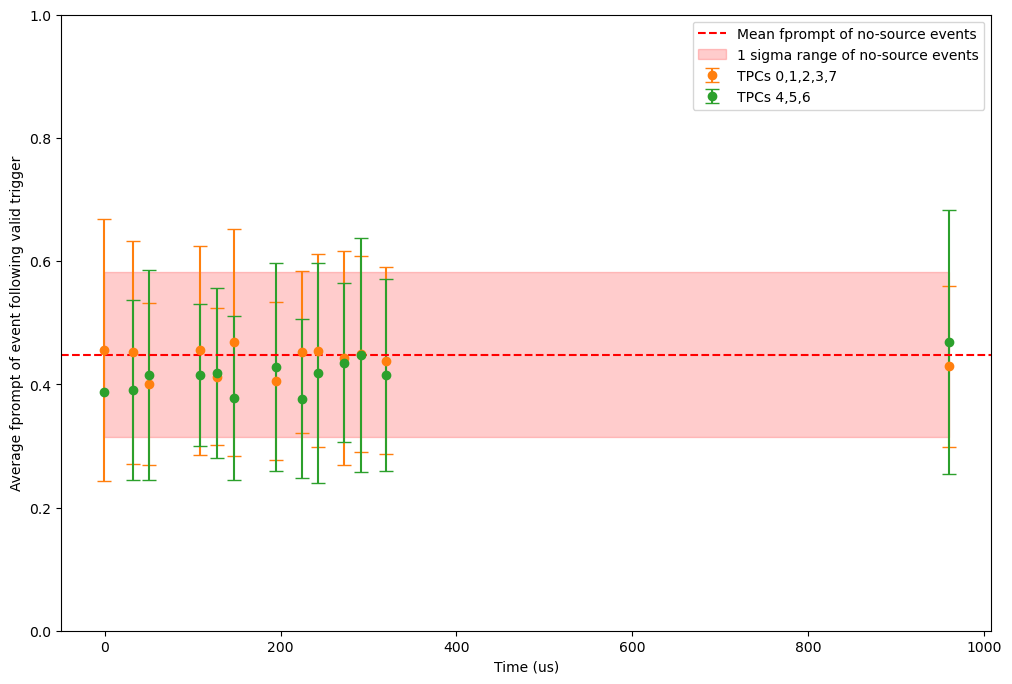

In [188]:
# Group by tpc and get the average fprompt per tpc
avg_fprompt_tpc = df_fprompts.groupby(["time", "tpc"])["fprompt"].mean().reset_index()
std_fprompt_tpc = df_fprompts.groupby(["time", "tpc"])["fprompt"].std().reset_index()

# Make a plot of fprompt vs time for each tpc
plt.figure(figsize=(12, 8))
for tpc in avg_fprompt_tpc["tpc"].unique():
    if tpc in [4,5]:
        # tpc_data = avg_fprompt_tpc[avg_fprompt_tpc["tpc"] == tpc]
        # tpc_std = std_fprompt_tpc[std_fprompt_tpc["tpc"] == tpc]
        # plt.errorbar(tpc_data["time"], tpc_data["fprompt"], yerr=tpc_std["fprompt"], fmt="o", capsize=5, label=f"TPC {tpc}")#, color='tab:blue')
        # average the fprompt values for tpcs 4,5,6 together
        avg_456 = avg_fprompt_tpc[avg_fprompt_tpc["tpc"].isin([4,5])].groupby("time")["fprompt"].mean().reset_index()
        std_456 = std_fprompt_tpc[std_fprompt_tpc["tpc"].isin([4,5])].groupby("time")["fprompt"].mean().reset_index()

    if tpc in [0, 1, 2, 3, 6, 7] :
        # tpc_data = avg_fprompt_tpc[avg_fprompt_tpc["tpc"] == tpc]
        # tpc_std = std_fprompt_tpc[std_fprompt_tpc["tpc"] == tpc]
        # plt.errorbar(tpc_data["time"], tpc_data["fprompt"], yerr=tpc_std["fprompt"], fmt="o", capsize=5, label=f"TPC {tpc}")#, color='tab:orange')
        # average the fprompt values for tpcs 0,1,2,3,7 together
        avg_01327 = avg_fprompt_tpc[avg_fprompt_tpc["tpc"].isin([0,1,2,3,6,7])].groupby("time")["fprompt"].mean().reset_index()
        std_01327 = std_fprompt_tpc[std_fprompt_tpc["tpc"].isin([0,1,2,3,6,7])].groupby("time")["fprompt"].mean().reset_index()
plt.errorbar(avg_01327["time"], avg_01327["fprompt"], yerr=std_01327["fprompt"], fmt="o", capsize=5, label="TPCs 0,1,2,3,7", color='tab:orange')
plt.errorbar(avg_456["time"], avg_456["fprompt"], yerr=std_456["fprompt"], fmt="o", capsize=5, label="TPCs 4,5,6", color='tab:green')

plt.axhline(mean_bg, color="red", linestyle="--", label="Mean fprompt of no-source events")
plt.fill_between(avg_fprompt["time"], mean_bg - std_bg, mean_bg + std_bg, color="red", alpha=0.2, label="1 sigma range of no-source events")
plt.xlabel("Time (us)")
plt.ylabel("Average fprompt of event following valid trigger")
plt.ylim(0, 1)
plt.legend()
plt.show()

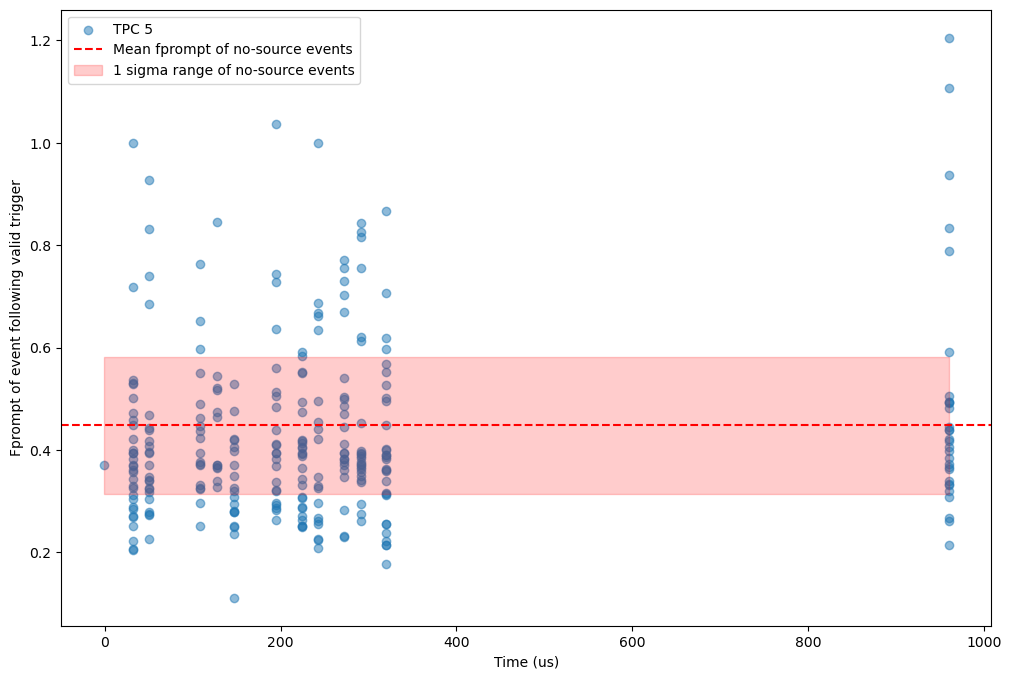

In [189]:
# Let's plot a scatter plot of fprompt vs time for each tpc
plt.figure(figsize=(12, 8))
for tpc in [5]:
    tpc_data = df_fprompts[df_fprompts["tpc"] == tpc]
    plt.scatter(tpc_data["time"], tpc_data["fprompt"], alpha=0.5, label=f"TPC {tpc}")
plt.axhline(mean_bg, color="red", linestyle="--", label="Mean fprompt of no-source events")
plt.fill_between(avg_fprompt["time"], mean_bg - std_bg, mean_bg + std_bg, color="red", alpha=0.2, label="1 sigma range of no-source events")
plt.xlabel("Time (us)")
plt.ylabel("Fprompt of event following valid trigger")
plt.legend()
plt.show()

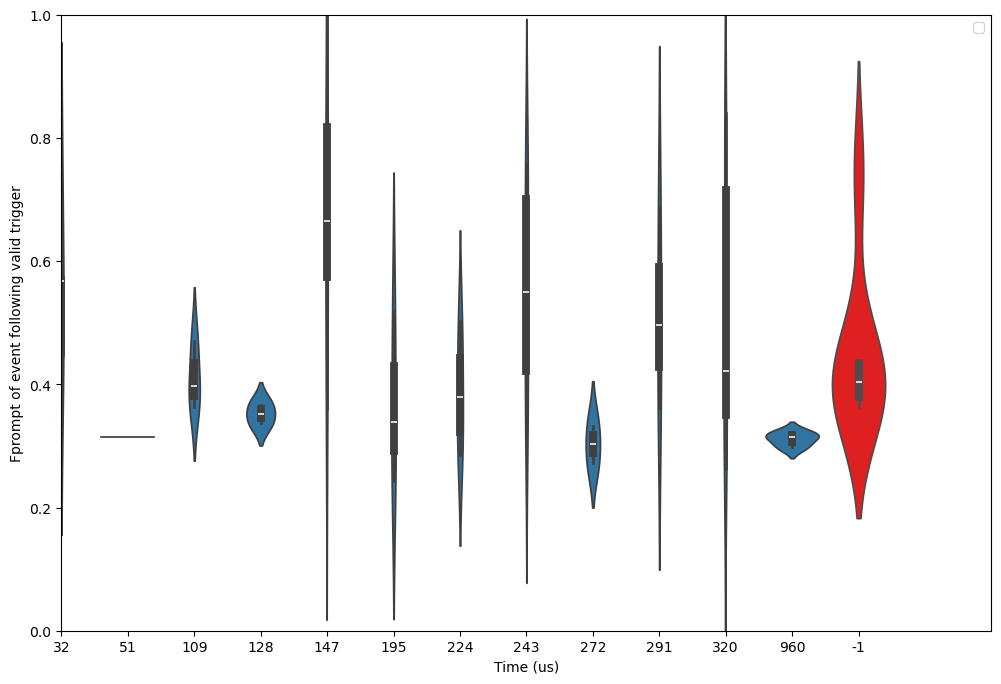

In [190]:
# I want a violin plot of the fprompt distribution for each time bin, separated by tpc
plt.figure(figsize=(12, 8))
import seaborn as sns
sns.violinplot(data=df_fprompts[df_fprompts["tpc"] == 0], x="time", y="fprompt")
# plt.axhline(mean_bg, color="red", linestyle="--", label="Mean fprompt of no-source events")
# plt.fill_between(avg_fprompt["time"], mean_bg - std_bg, mean_bg + std_bg, color="red", alpha=0.2, label="1 sigma range of no-source events")
# plot the violin plot for background events with time -1
sns.violinplot(data=df_fprompts[df_fprompts["time"] == -1], x="time", y="fprompt", color="red")
plt.xlabel("Time (us)")
plt.ylabel("Fprompt of event following valid trigger")
plt.xlim(0, 14)
plt.ylim(0, 1)
plt.legend()
plt.show()

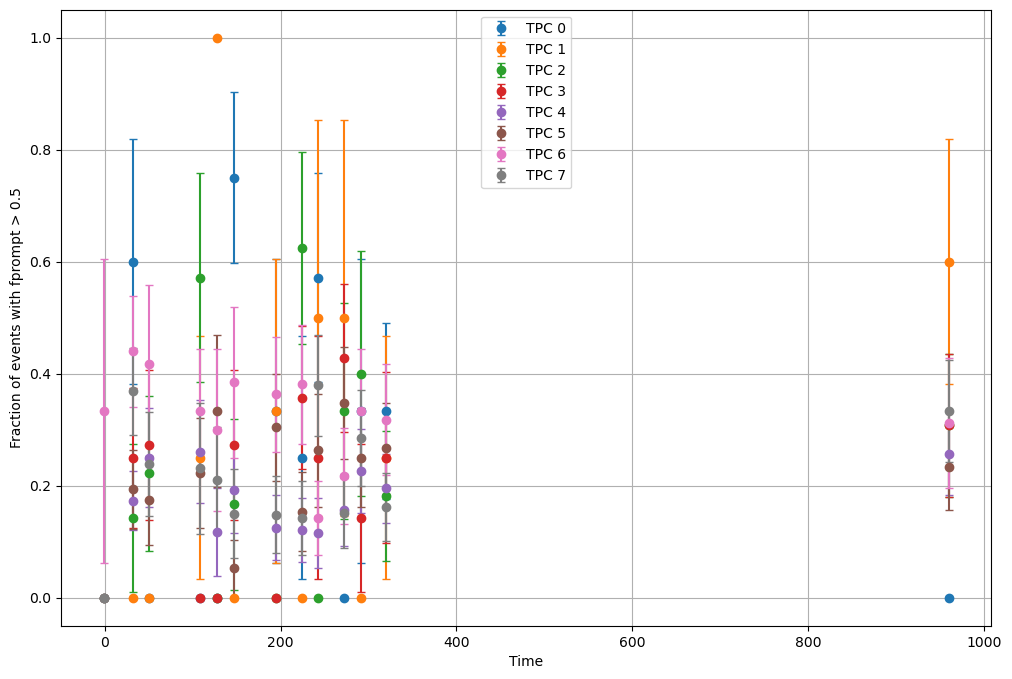

In [219]:
# For each time bin and each tpc I want to calculate the fraction of events that have an fprompt above 0.5, and plot that as a function of time for each tpc

threshold = 0.5

# boolean column: event passes threshold
df_fprompts["is_high"] = df_fprompts["fprompt"] > threshold

# compute fraction per (time, tpc)
stats = (
    df_fprompts
    .groupby(["time", "tpc"])
    .agg(
        fraction=("is_high", "mean"),
        n_events=("is_high", "size"),
        n_high=("is_high", "sum")
    )
    .reset_index()
)
stats["error"] = np.sqrt(
    stats["fraction"] * (1 - stats["fraction"]) / stats["n_events"]
)
plt.figure(figsize=(12,8))

for tpc in range(8):
    data = stats[stats["tpc"] == tpc]

    plt.errorbar(
        data["time"],
        data["fraction"],
        yerr=data["error"],
        marker="o",
        ls='none',
        capsize=3,
        label=f"TPC {tpc}"
    )

plt.xlabel("Time")
plt.ylabel("Fraction of events with fprompt > 0.5")
plt.legend()
plt.grid(True)
plt.show()




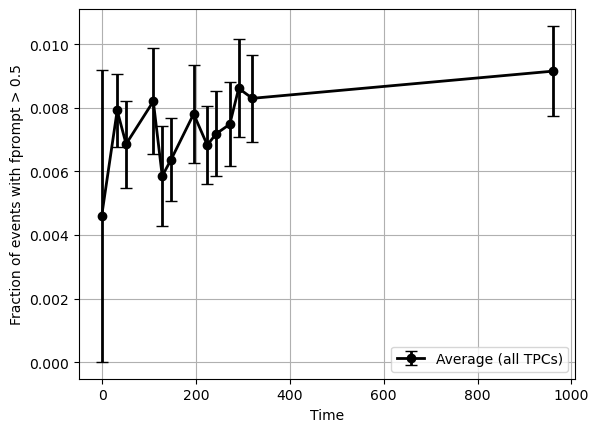

In [222]:
avg_stats = (
    df_fprompts
    .groupby("time")
    .agg(
        fraction=("is_high", "mean"),
        n_events=("is_high", "size"),
        n_high=("is_high", "sum")
    )
    .reset_index()
)
avg_stats["fraction"] = avg_stats["n_high"] / avg_stats["n_events"]
avg_stats["error"] = np.sqrt(
    avg_stats["fraction"] * (1 - avg_stats["fraction"]) / avg_stats["n_events"]
)
plt.errorbar(
    avg_stats["time"],
    avg_stats["fraction"],
    yerr=avg_stats["error"],
    color="black",
    linewidth=2,
    marker="o",
    capsize=4,
    label="Average (all TPCs)"
)
plt.xlabel("Time")
plt.ylabel("Fraction of events with fprompt > 0.5")
plt.legend()
plt.grid(True)
plt.show()

In [213]:
tpc_time_data

,time,fprompt,fraction,fraction_err
0,32,0.539805,0.416667,0.140119
1,51,0.314955,0.416667,0.140119
2,109,0.410383,0.416667,0.140119
3,128,0.352128,0.416667,0.140119
4,147,0.693649,0.416667,0.140119
5,195,0.367182,0.416667,0.140119
6,224,0.386778,0.416667,0.140119
7,243,0.552065,0.416667,0.140119
8,272,0.302513,0.416667,0.140119
9,291,0.514483,0.416667,0.140119


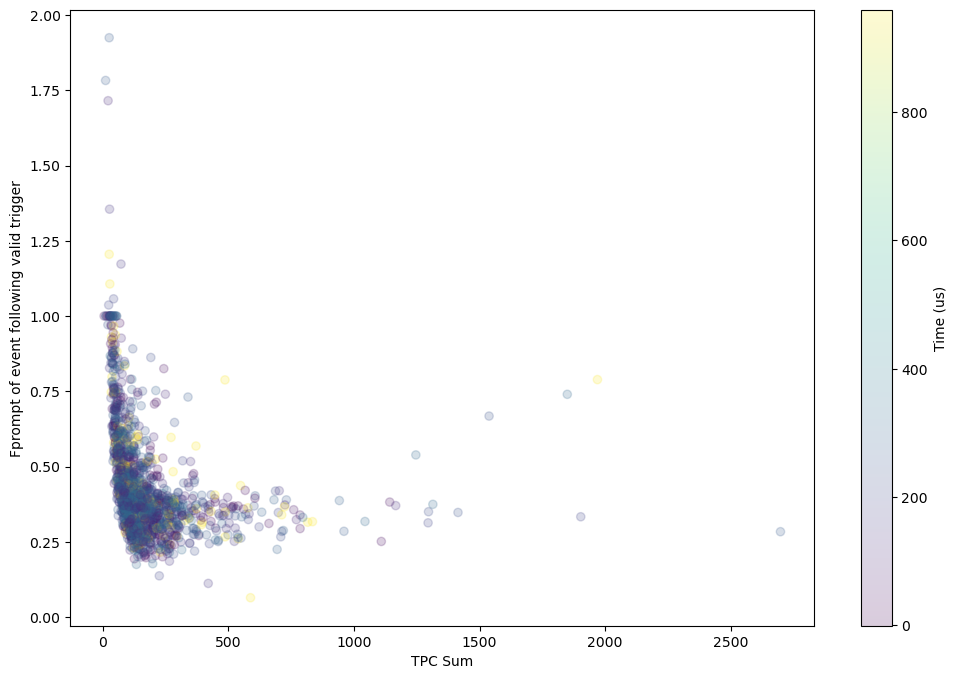

In [197]:
# plot also the fprompt vs tpc_sum for the valid events, colored by time
plt.figure(figsize=(12, 8))
plt.scatter(df_fprompts["tpc_sum"], df_fprompts["fprompt"], c=df_fprompts["time"], cmap="viridis", alpha=0.2)
plt.colorbar(label="Time (us)")
plt.xlabel("TPC Sum")
plt.ylabel("Fprompt of event following valid trigger")
plt.show()